# Aprire e mappare un dataset SST CMEMS

In questo notebook apriamo un file NetCDF di temperatura superficiale del mare (SST), ne esaminiamo struttura e metadati e rappresentiamo le prime otto mappe disponibili.

## 1. Librerie

In [1]:
from pathlib import Path

import xarray as xr

## 2. Individuazione e apertura del file

Il codice funziona sia avviando Jupyter dalla cartella principale del progetto sia dalla cartella `code`.

In [ ]:
nome_file = "cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021_1788948737782.nc" # Nome del file usato nell'esempio

In [ ]:
cwd = Path.cwd()  # Directory di lavoro corrente


In [ ]:
project_dir = cwd.parent # leggo la directory principale del progetto (una cartella sopra la directory di lavoro corrente)

In [ ]:


percorso = project_dir / "data" / nome_file  # Costruisco il percorso completo del file SST (che si trova nella sottocartella "data")


# Percorso completo del file SST
percorso

PosixPath('/Users/matzuc/Dropbox/R_projects/EMC-CC_2026_notebook/data/cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021_1788948737782.nc')

In [ ]:
ds = xr.open_dataset(percorso) # apro il dataset SST
ds # visualizzo il contenuto del dataset SST

<xarray.Dataset> Size: 32MB
Dimensions:       (time: 10959, latitude: 23, longitude: 32)
Coordinates:
  * time          (time) datetime64[ns] 88kB 1995-03-13 ... 2025-03-13
  * latitude      (latitude) float32 92B 42.56 42.61 42.66 ... 43.57 43.62 43.67
  * longitude     (longitude) float32 128B 13.1 13.15 13.2 ... 14.56 14.61 14.66
Data variables:
    analysed_sst  (time, latitude, longitude) float32 32MB ...
Attributes:
    Conventions:       CF-1.11
    title:             Mediterranean Sea SST Analysis L4, Reprocessed using E...
    institution:       GOS (Global Ocean Satellite monitoring and marine ecos...
    source:            [1982-present] ESA CCI SST v.3.0 L3C product (SST at 0...
    history:           GOS-CMEMS processor V4: new version
    references:        A. Pisano, B. Buongiorno Nardelli, C. Tronconi, R. San...
    comment:           WARNING: some applications are unable to properly hand...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SST_MED_SST_L4_REP_OBSERVATIONS_010_021
    subset:datasetId:  cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021_202411
    subset:date:       2026-09-09T10:12:17.782Z

## 3. Conversione in gradi Celsius

Se la temperatura è espressa in kelvin, la convertiamo in gradi Celsius.

In [ ]:
sst = ds - 273.15 # converto la temperatura da Kelvin a Celsius
sst["analysed_sst"].attrs["units"] = "°C" # aggiorno l'unità di misura della temperatura
sst["analysed_sst"].attrs["long_name"] = "Temperatura superficiale del mare" # aggiorno il nome lungo della variabile

sst # visualizzo il contenuto del dataset SST convertito in Celsius

<xarray.Dataset> Size: 32MB
Dimensions:       (time: 10959, latitude: 23, longitude: 32)
Coordinates:
  * time          (time) datetime64[ns] 88kB 1995-03-13 ... 2025-03-13
  * latitude      (latitude) float32 92B 42.56 42.61 42.66 ... 43.57 43.62 43.67
  * longitude     (longitude) float32 128B 13.1 13.15 13.2 ... 14.56 14.61 14.66
Data variables:
    analysed_sst  (time, latitude, longitude) float32 32MB nan nan ... 14.48
Attributes:
    Conventions:       CF-1.11
    title:             Mediterranean Sea SST Analysis L4, Reprocessed using E...
    institution:       GOS (Global Ocean Satellite monitoring and marine ecos...
    source:            [1982-present] ESA CCI SST v.3.0 L3C product (SST at 0...
    history:           GOS-CMEMS processor V4: new version
    references:        A. Pisano, B. Buongiorno Nardelli, C. Tronconi, R. San...
    comment:           WARNING: some applications are unable to properly hand...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SST_MED_SST_L4_REP_OBSERVATIONS_010_021
    subset:datasetId:  cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021_202411
    subset:date:       2026-09-09T10:12:17.782Z

## 4. Prime otto mappe

Usiamo gli stessi limiti della scala cromatica in tutti i pannelli, così le date sono confrontabili. I limiti sono calcolati usando il 2° e il 98° percentile delle prime otto mappe.

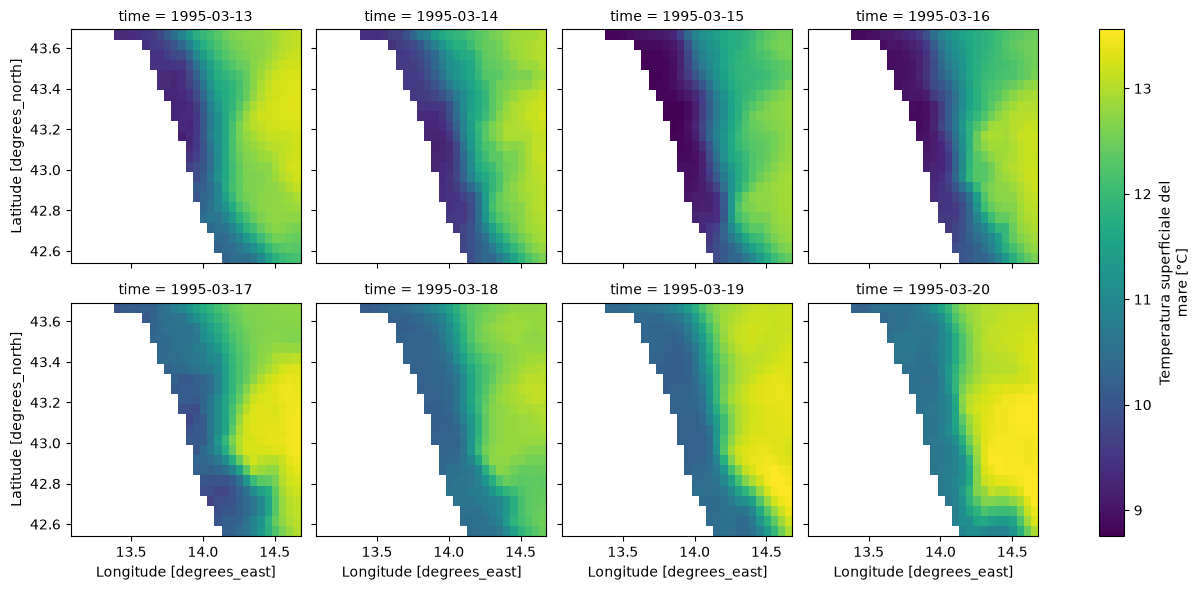

In [ ]:
sst["analysed_sst"].isel(time=slice(0, 8)).plot(
    col="time",
    col_wrap=4
) # visualizzo le prime 8 mappe temporali della temperatura superficiale del mare

## 5. Chiusura del dataset

Chiudiamo esplicitamente il file NetCDF quando abbiamo terminato l'analisi.

In [46]:
ds.close()